In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(rc={'figure.figsize':(11.7,8.27)})
pd.options.display.float_format = '{:20,.2f}'.format
import os
import chardet

## Создание датасета

In [2]:
import re
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import spacy
from sentence_transformers import SentenceTransformer
from nltk.corpus import stopwords
import nltk

In [3]:
text = pd.read_excel('./new_data_almazov.xlsx')

In [4]:
# Загрузка ресурсов
nltk.download('stopwords')
stopwords_ru = set(stopwords.words("russian"))
nlp = spacy.load("ru_core_news_sm")
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\emil_\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

C:\Users\emil_\anaconda3\lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\emil_\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [38]:
def clean_segment(segment):
    """Очистка и лемматизация ОДНОГО сегмента."""
    text = str(segment).lower()
    text = re.sub(r'[^а-яё\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    doc = nlp(text)
    lemmas = [token.lemma_ for token in doc if token.text not in stopwords_ru and len(token.text) > 1]
    
    return " ".join(lemmas)

def enhanced_syntactic_segmentation(text):
    """Синтаксическая сегментация на сыром тексте."""
    segments = []
    
    # Шаг 1: Разделение по строкам
    for line in text.split('\n'):
        line = line.strip()
        if not line:
            continue
        
        # Шаг 2: Разделение по предложениям (spaCy)
        doc = nlp(line)
        for sent in doc.sents:
            sent_text = sent.text.strip()
            if not sent_text:
                continue
            
            # Шаг 3: Для длинных предложений — разбиение по запятым/двоеточиям
            if len(sent_text.split()) > 15:
                sub_segments = re.split(r'[,:;]', sent_text)
                for sub in sub_segments:
                    sub = sub.strip()
                    if sub and len(sub.split()) > 2:
                        segments.append(sub)
            else:
                segments.append(sent_text)
    
    return segments

def hybrid_segmentation(text, similarity_threshold=0.2, min_words=3):
    """
    Гибридная сегментация: синтаксическая + семантическая.
    """
    # Шаг 1: Синтаксическая сегментация
    segments = enhanced_syntactic_segmentation(text)
    
    if len(segments) <= 1:
        return segments
    
    # Шаг 2: Семантическая сегментация (объединение близких по смыслу)
    embeddings = model.encode(segments)
    similarities = cosine_similarity(embeddings)
    
    final_segments = []
    current = segments[0]
    
    for i in range(1, len(segments)):
        sim = similarities[i-1, i]
        
        # Объединяем, если семантически близки
        if sim > similarity_threshold:
            current += " " + segments[i]
        else:
            if len(current.split()) >= min_words:
                final_segments.append(current)
            current = segments[i]
    
    if len(current.split()) >= min_words:
        final_segments.append(current)
    
    return final_segments if final_segments else segments

def process_text_hybrid(text):
    """
    Полный пайплайн: гибридная сегментация → очистка → лемматизация.
    """
    # 1. Сегментация на сыром тексте
    raw_segments = hybrid_segmentation(str(text))
    
    # 2. Очистка и лемматизация каждого сегмента
    processed = []
    for seg in raw_segments:
        cleaned = clean_segment(seg)
        if len(cleaned.split()) >= 3:
            processed.append(cleaned)
    
    return processed

In [39]:
print(f"Изначальное количество записей: {len(text)}")

Изначальное количество записей: 44358


In [40]:
# Применяем обработку
text['processed_text'] = text['рекомендации общие'].apply(process_text_hybrid)
text_exploded = text.explode('processed_text')
text_exploded = text_exploded[text_exploded['processed_text'] != '']
text_exploded = text_exploded[text_exploded['processed_text'].notna()]

In [41]:
print(f"Количество записей после обработки: {len(text_exploded)}")
print(text_exploded[['processed_text']].head(10))

Количество записей после обработки: 34351
                                         processed_text
4413  общий рекомендация контроль давление пульс раз...
4415  общий рекомендация ограничение потребление про...
4415  предпочтительно овощ цельнозерновых продукт ов...
4424  режим нагрузка общий рекомендация контроль дав...
4454  общий рекомендация контроль ад пульс раз день ...
4514  общий рекомендация контроль давление пульс раз...
4559  общий рекомендация контроль давление пульс раз...
4567  общий рекомендация контроль давление пульс раз...
4577  режим нагрузка общий рекомендация ежедневный к...
4585  режим нагрузка общий рекомендация ежедневный к...


In [42]:
text_exploded = text_exploded[text_exploded['processed_text'].str.strip() != '']

In [43]:
text_exploded.columns

Index(['Регистрационный номер', 'Номер эпизода', 'Пол', 'возраст',
       'найдено в разделах', 'диета', 'найдено в диете', 'рекомендации общие',
       'найдено в рекомендациях общих', 'рекомендации дополнительные',
       'найдено в рекомендациях дополнительных', 'медикаментозная терапия',
       'найдено в медикаментозной терапии', 'консультации специалистов',
       'найдено в консультациях специалистов', 'лабораторные исследования',
       'найдено в лабораторных исследованиях', 'инструментальные исследования',
       'найдено в инструментальных исследованиях',
       'рекомендации неструктурированные',
       'найдено в рекомендациях неструктурированных', 'Код диагноза',
       'стадия заболевания', 'степень тяжести', 'АГ',
       'контролируемость расчётная', 'Описание диагноза', 'Код отделения',
       'ФИО специалиста', 'Дата время выполнения',
       'артериальное давление на правой руке систолическое',
       'артериальное давление на правой руке диастолическое',
       'арт

In [44]:
text_exploded = text_exploded[['Регистрационный номер', 'Номер эпизода', 'ФИО специалиста', 'Дата время выполнения', 'processed_text']]

In [45]:
text_exploded = text_exploded[text_exploded['processed_text'].apply(lambda x: len(x.split())) > 2]

In [46]:
text_exploded.head()

,Регистрационный номер,Номер эпизода,ФИО специалиста,Дата время выполнения,processed_text
4413,6612/A19,13654/А2019,Гордеева Мария Сергеевна,2019-03-06 15:00:00.000,общий рекомендация контроль давление пульс раз...
4415,5382/A19,NaN,Гордеева Мария Сергеевна,2019-03-06 15:30:00.000,общий рекомендация ограничение потребление про...
4415,5382/A19,NaN,Гордеева Мария Сергеевна,2019-03-06 15:30:00.000,предпочтительно овощ цельнозерновых продукт ов...
4424,16663/A19,NaN,Гордеева Мария Сергеевна,2019-03-06 17:30:00.000,режим нагрузка общий рекомендация контроль дав...
4454,16322/A19,NaN,Гордеева Мария Сергеевна,2019-03-07 18:00:00.000,общий рекомендация контроль ад пульс раз день ...


In [47]:
text_exploded['processed_text'][44352].values

array(['коррекция вес снижение избыточный масса тело индекс масса тело менее кг нормализация режим труд отдых снижение стрессовый нагрузка дозированные физический нагрузка ходьба регулярный аэробный упражнение физический активность менее мина ежедневно контроль общий самочувствие',
       'эффективный фн должный приводить увеличение пульс менее контроль ад пульс раз день дневник'],
      dtype=object)

In [48]:
init_df = pd.read_excel('./new_data_almazov.xlsx')
init_df.loc[init_df['Регистрационный номер']=='47611/A21']['рекомендации общие'].values

array(['Коррекция веса (снижение избыточной массы тела). Индекс массы тела менее 25 кг/м Нормализация режима труда и отдыха. Снижение стрессовых нагрузок.  Дозированные физические нагрузки (ходьба, утренняя гимнастика, регулярные аэробные упражнения) – физическая активность (не менее 30 мин. ежедневно – под контролем общего самочувствия). Эффективная ФН должна приводить к увеличению пульса не менее чем на 30%,  Избегать переутомления, эмоциональных нагрузок. Контроль АД и пульса * 2 раза в день (дневник)'],
      dtype=object)

In [14]:
text_exploded.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 44618 entries, 4413 to 44357
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Регистрационный номер  44618 non-null  object
 1   Номер эпизода          27808 non-null  object
 2   ФИО специалиста        44618 non-null  object
 3   Дата время выполнения  44618 non-null  object
 4   processed_text         44618 non-null  object
dtypes: object(5)
memory usage: 2.0+ MB


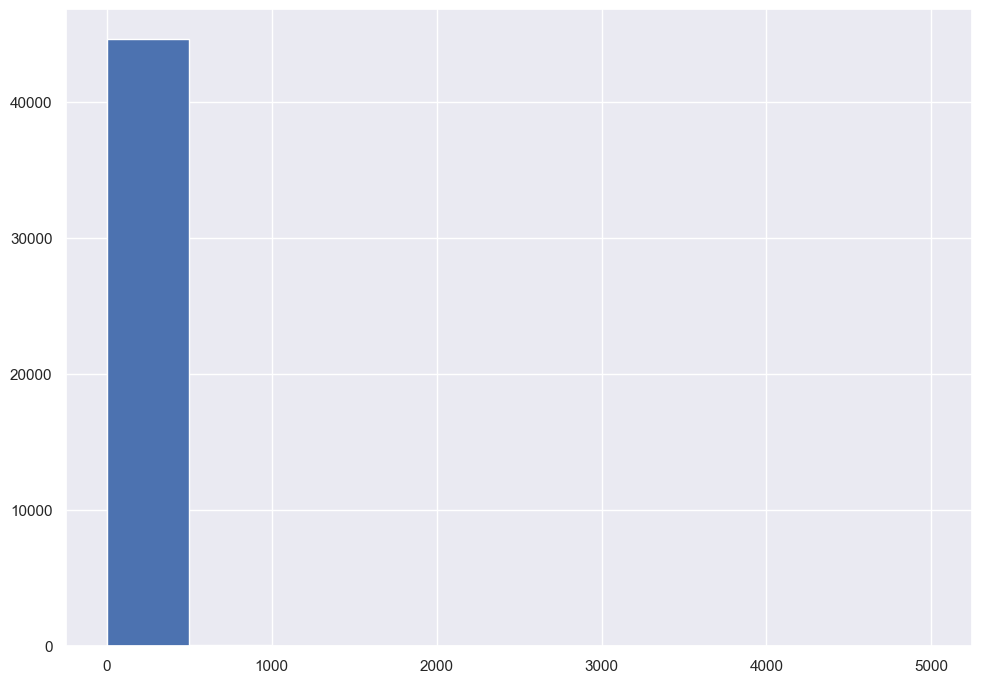

In [15]:
text_exploded['processed_text'].apply(len).hist(range=(0, 5000));

In [18]:
text_exploded.reset_index(drop=True, inplace=True)

In [19]:
# text_exploded.to_csv('processed_text_almazov.csv', index=False)